In [8]:
import numpy as np
from matplotlib import pyplot as plt

import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

from functions.read_g4bl_data import readTraceData
from functions.calculate_fields import calculate_Br_rotated, calculate_Br_analytic
import functions.plot_trace as plot
from functions.set_plot_settings import setPlotSettings
from functions.calculate_focusing_length import calculateF
setPlotSettings(font=True)

# Location of G4bl output file:
file = 'g4bl-output/AllTracks.txt'

# Select event ID:
# eventID = -2 # reference
eventID = 1 # with initial conditions

# Length of coil (mm):
L = 100

# Parameters for plotting solenoids:
n = 1
d = 0
zshift = 0

In [9]:
# Read in data:
data = readTraceData(file)
data = data[data['EventID']==eventID]

### Fields in lab frame

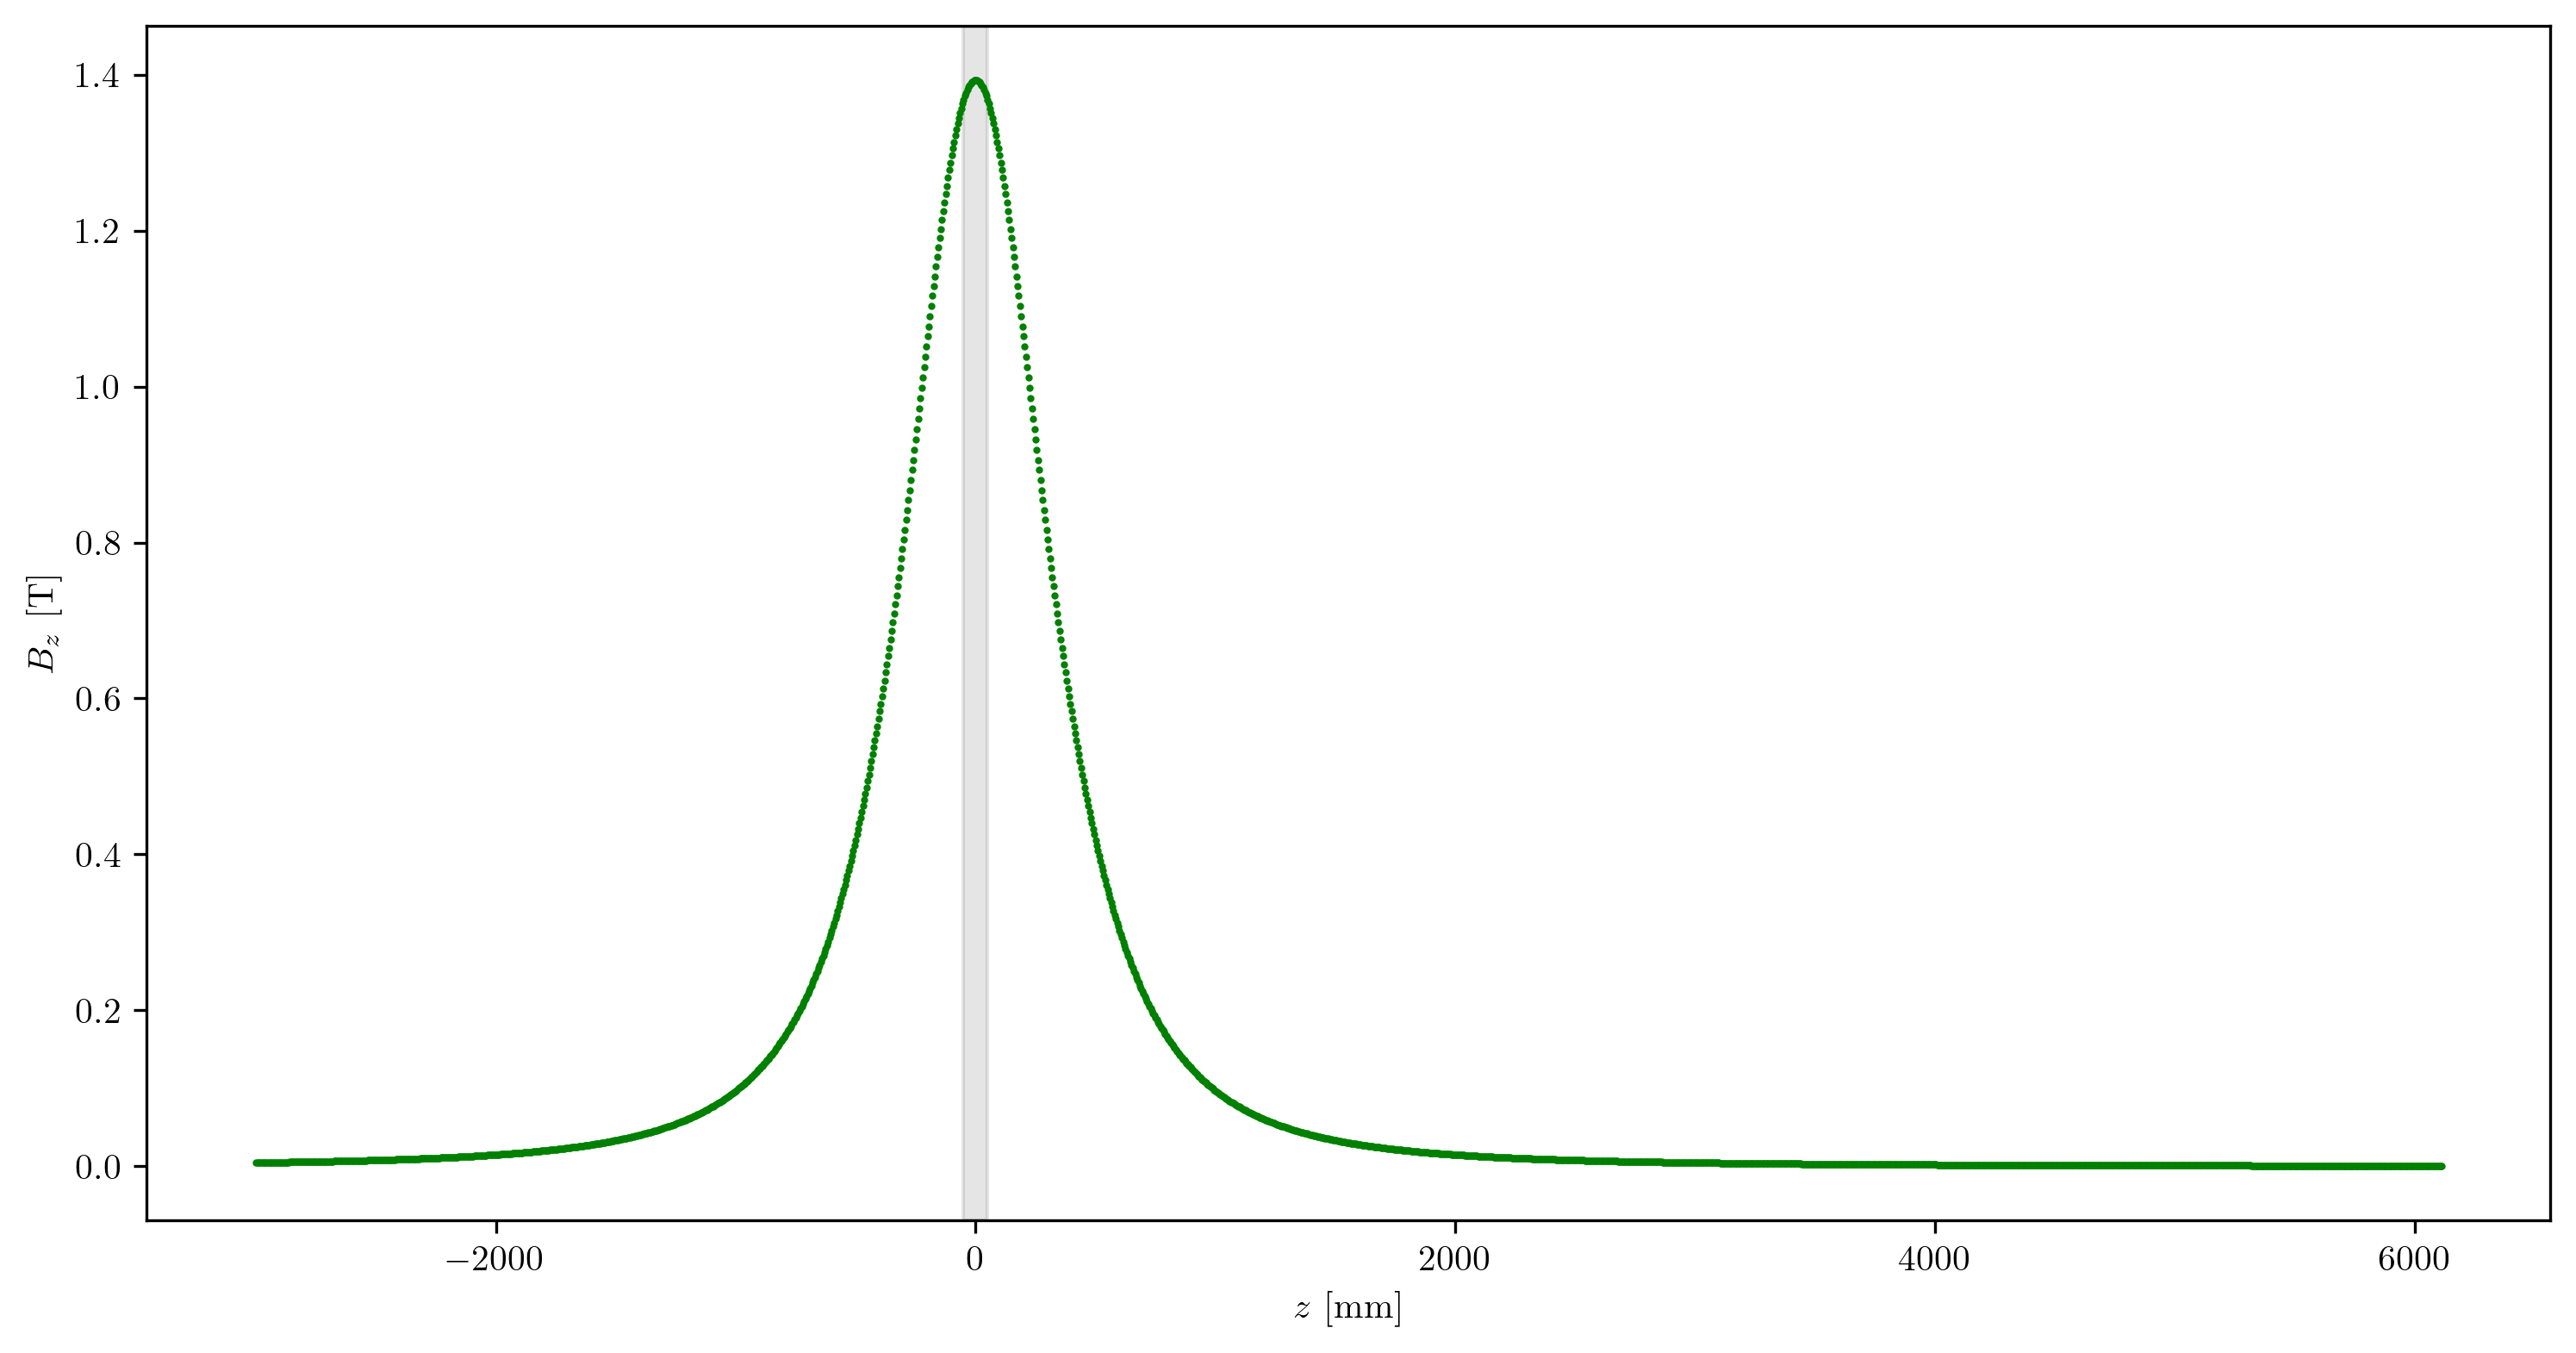

In [10]:
# Plot B_z vs. z:
plt.figure(figsize=(12,6))
plot.plot_solenoids(n=n, d=d, L=L, zshift=zshift)
plot.plot_Bz(data)
plt.show()

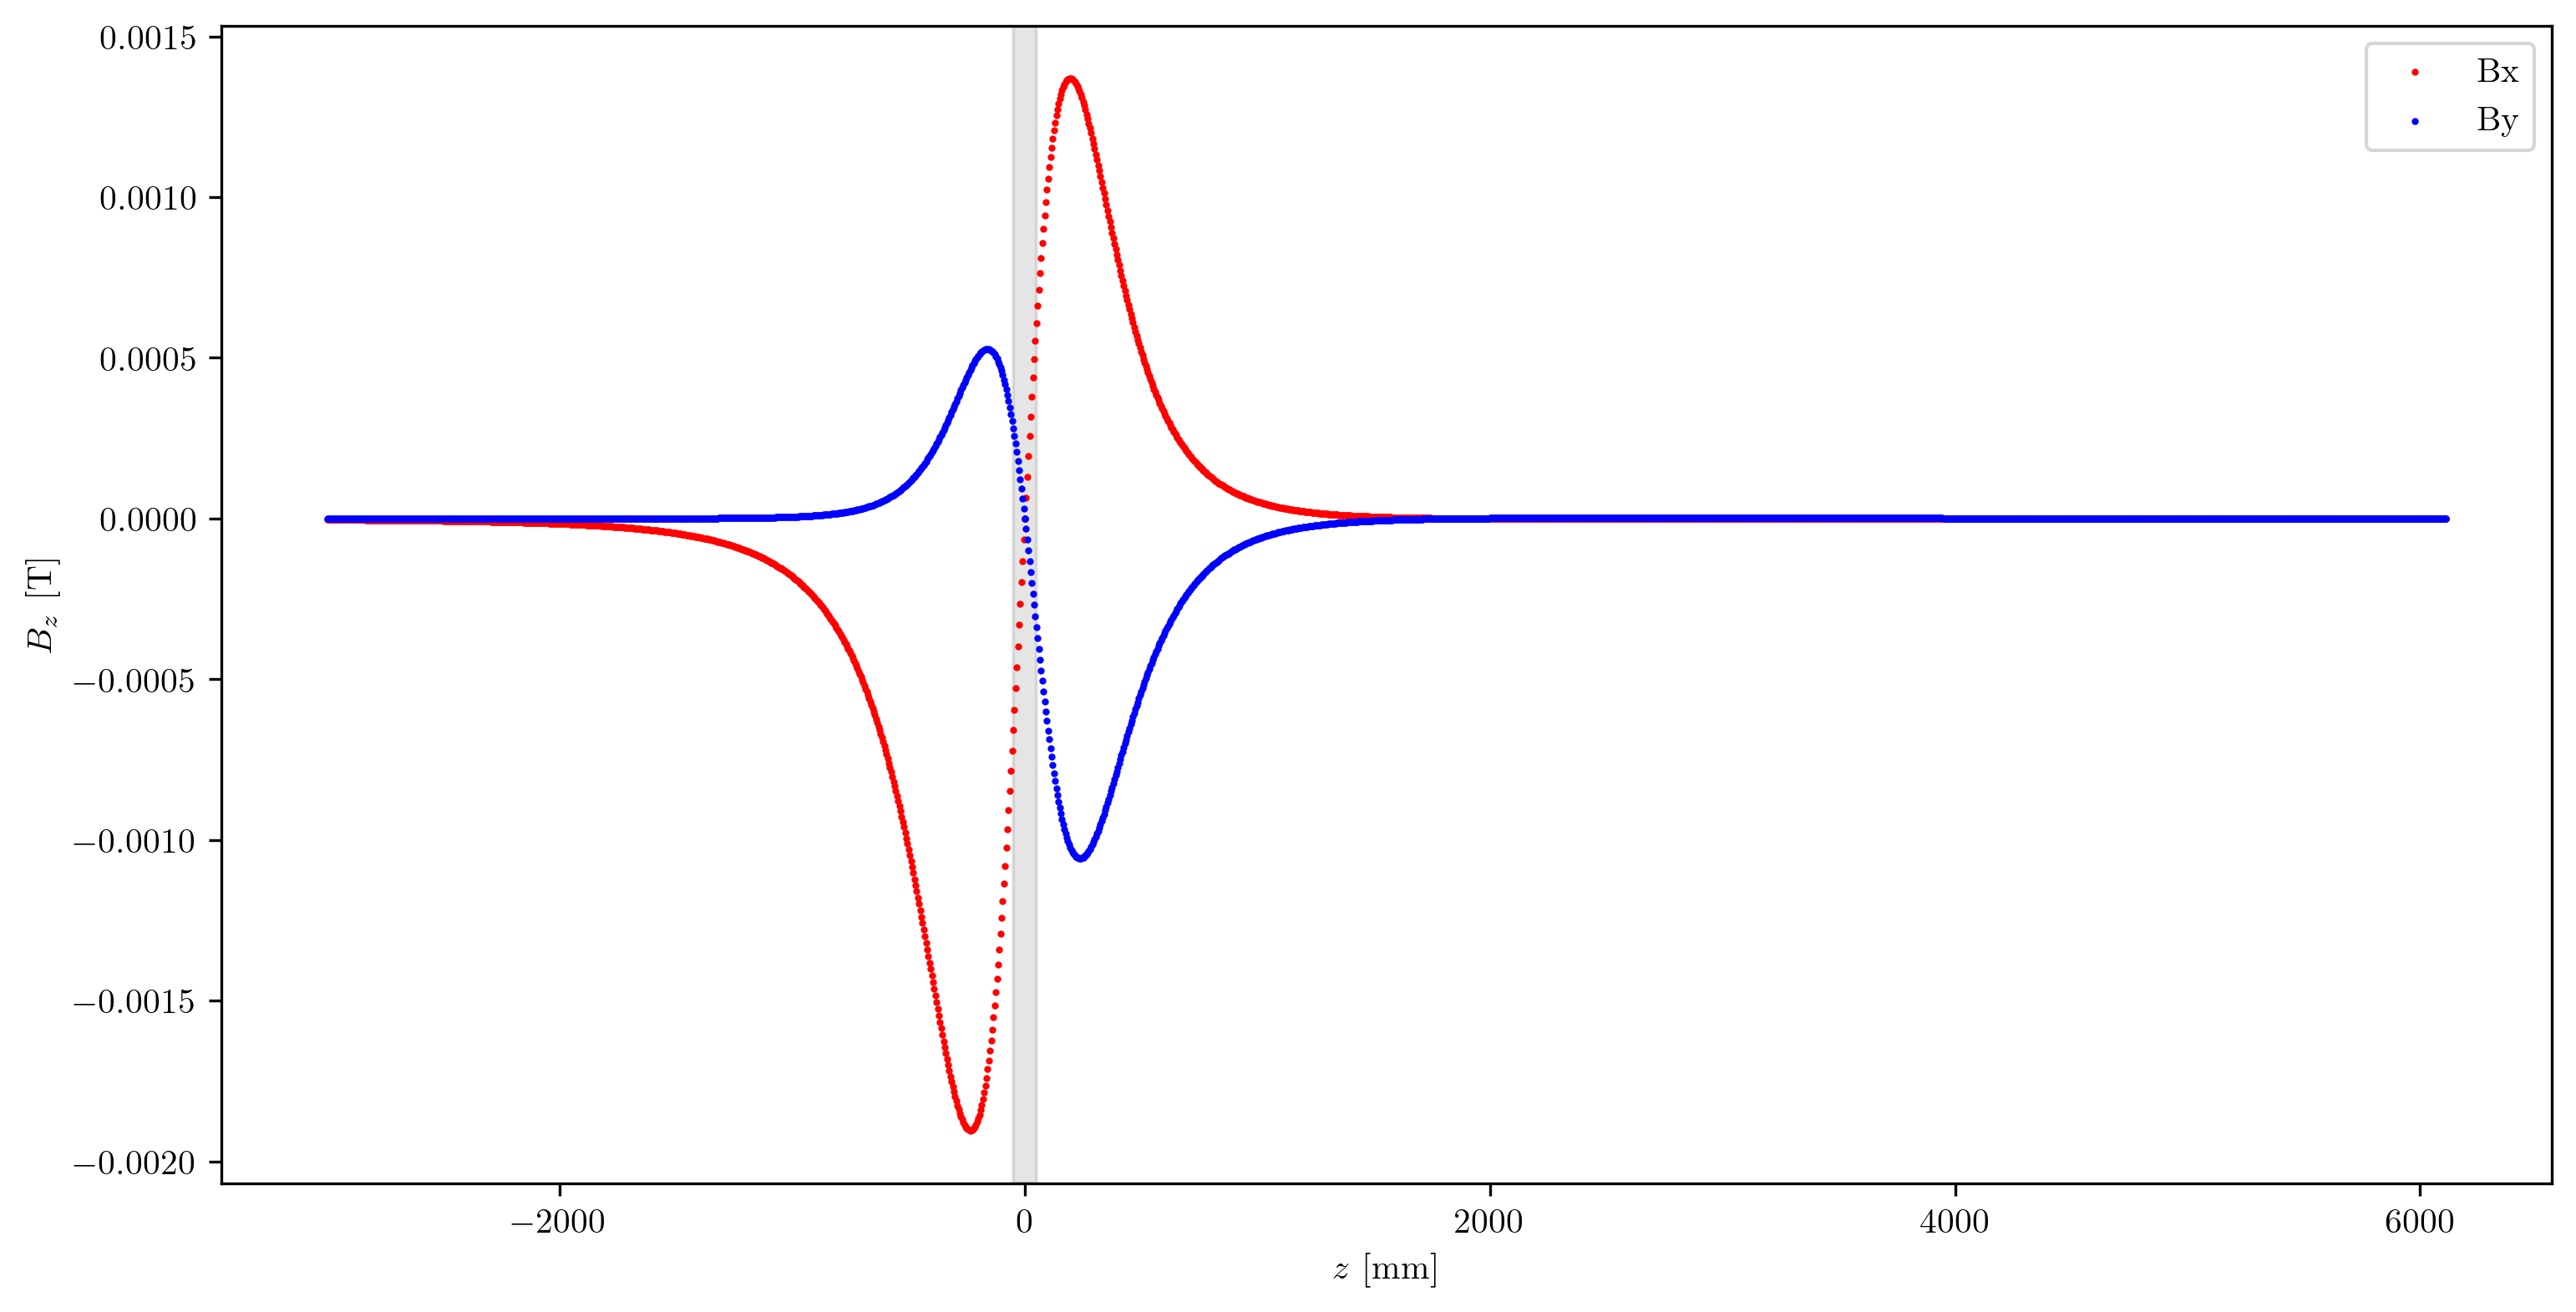

In [11]:
# Plot B_x, B_y vs. z:
plt.figure(figsize=(12,6))
plot.plot_solenoids(n=n, d=d, L=L, zshift=zshift)
plot.plot_Btrans(data)
plt.show()

### Particle dynamics

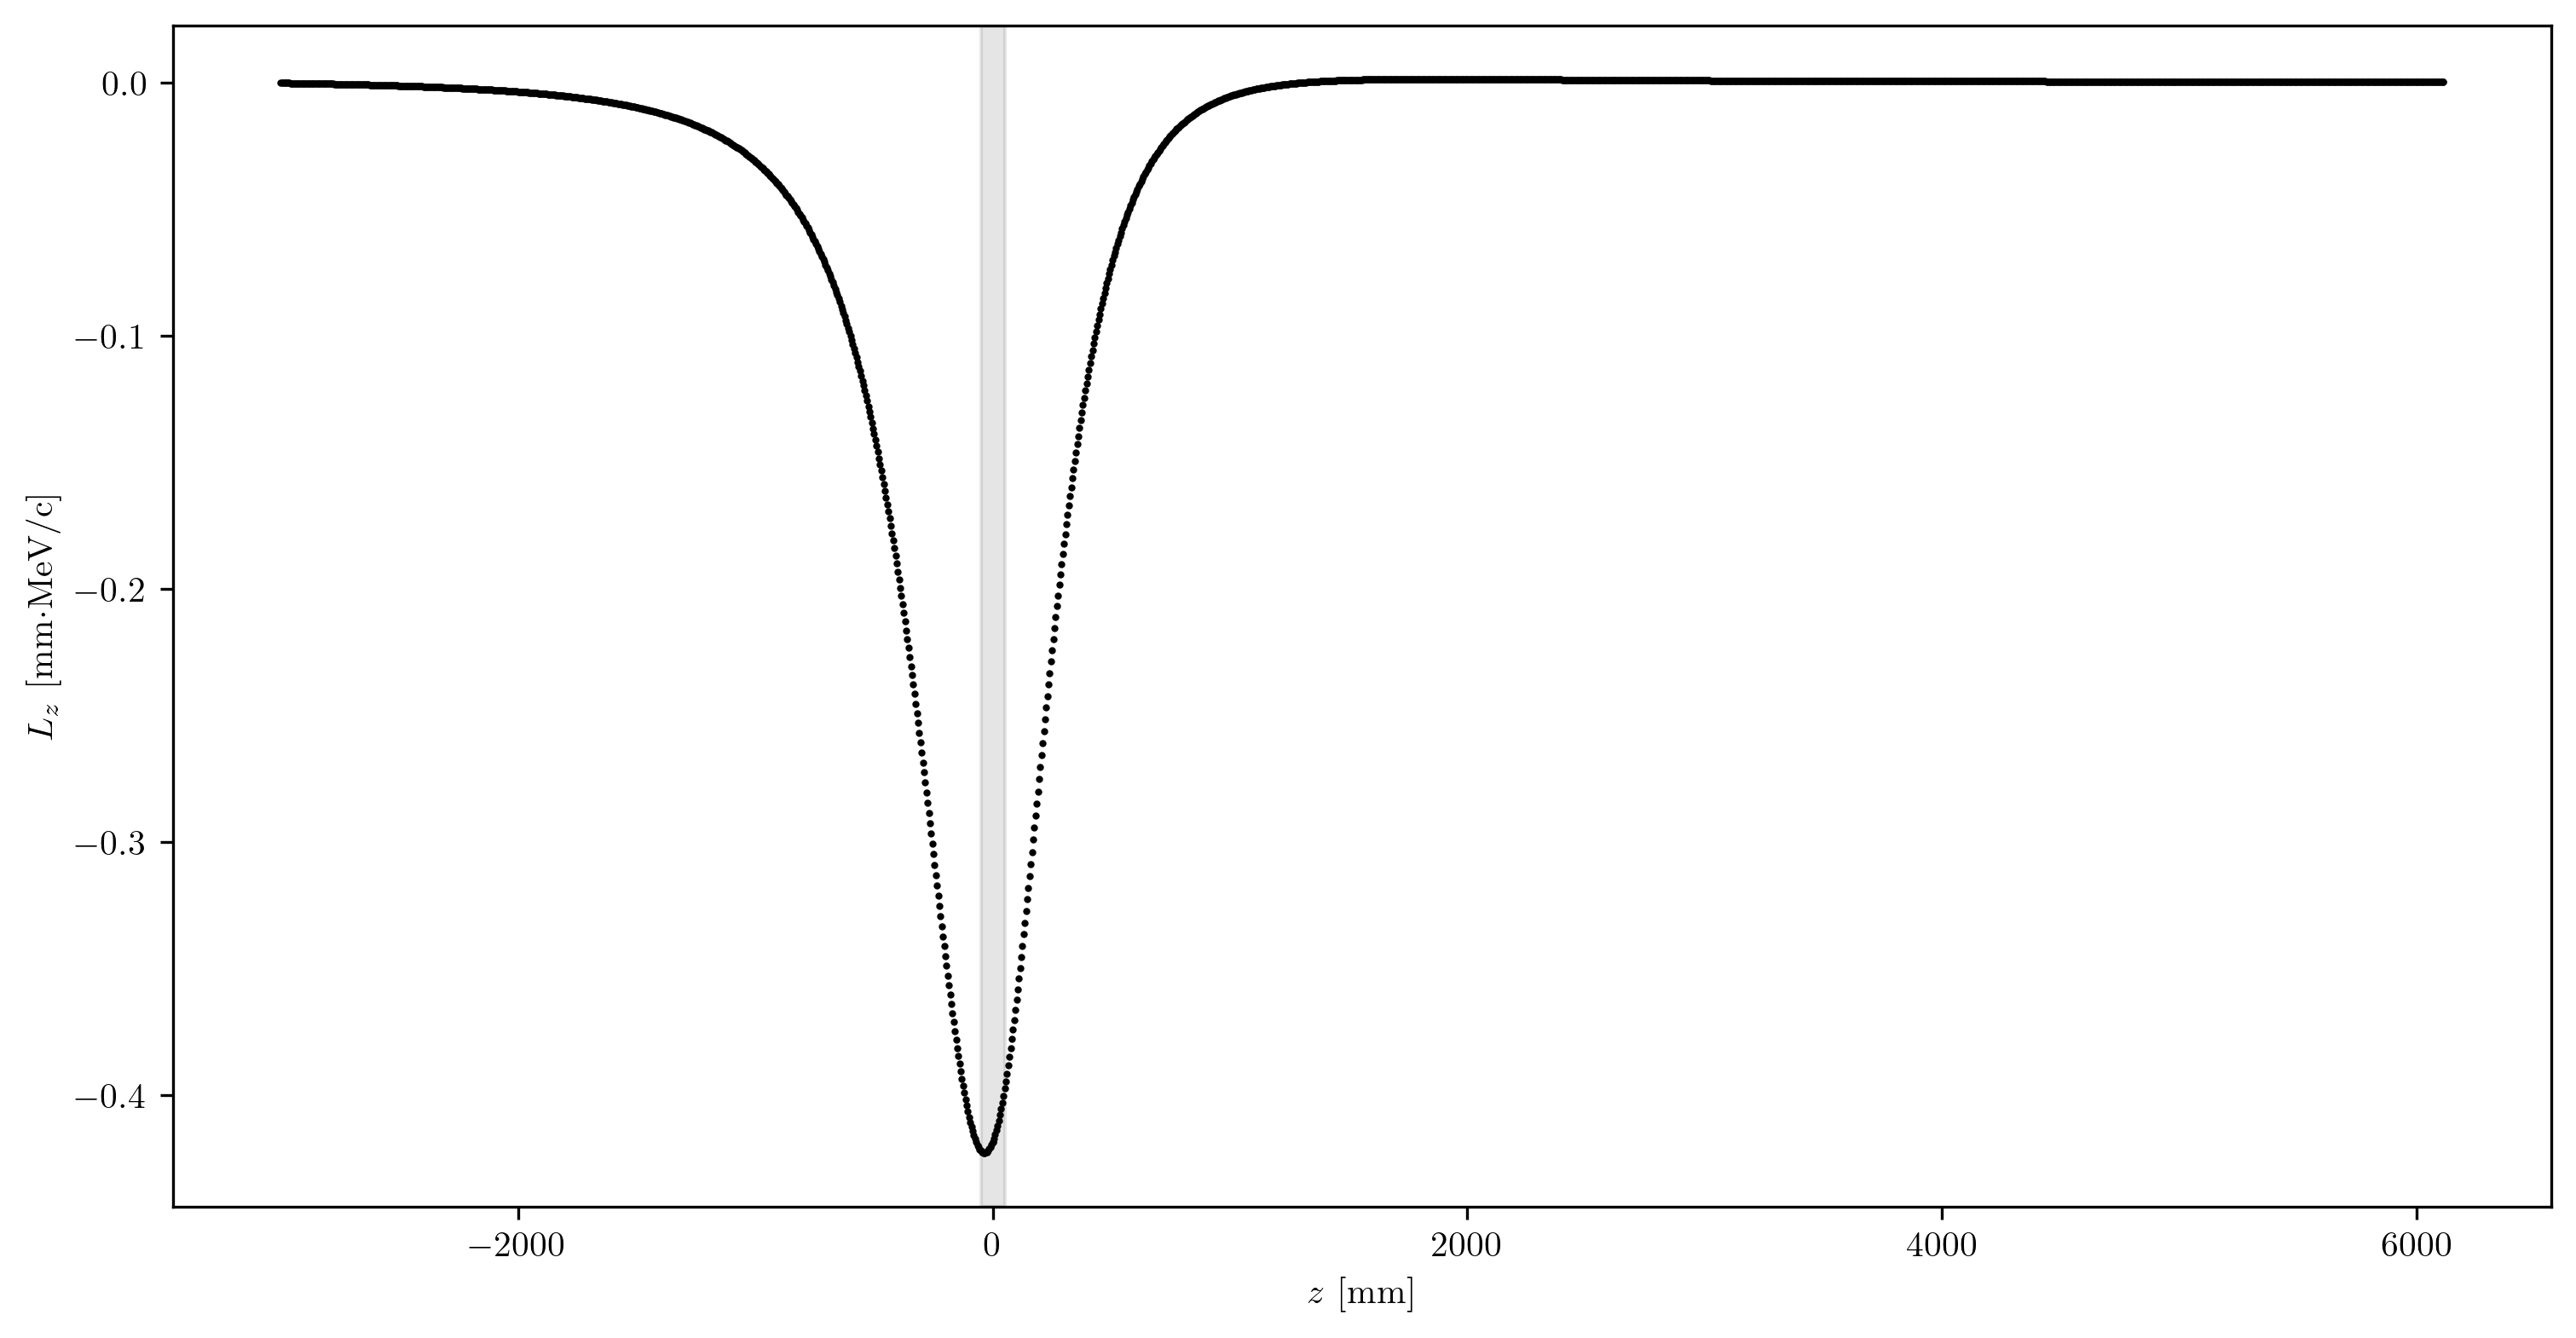

In [12]:
# Plot L_z vs. z:
plt.figure(figsize=(12,6))
plot.plot_solenoids(n=n, d=d, L=L, zshift=zshift)
plot.plot_Lz(data)
plt.show()

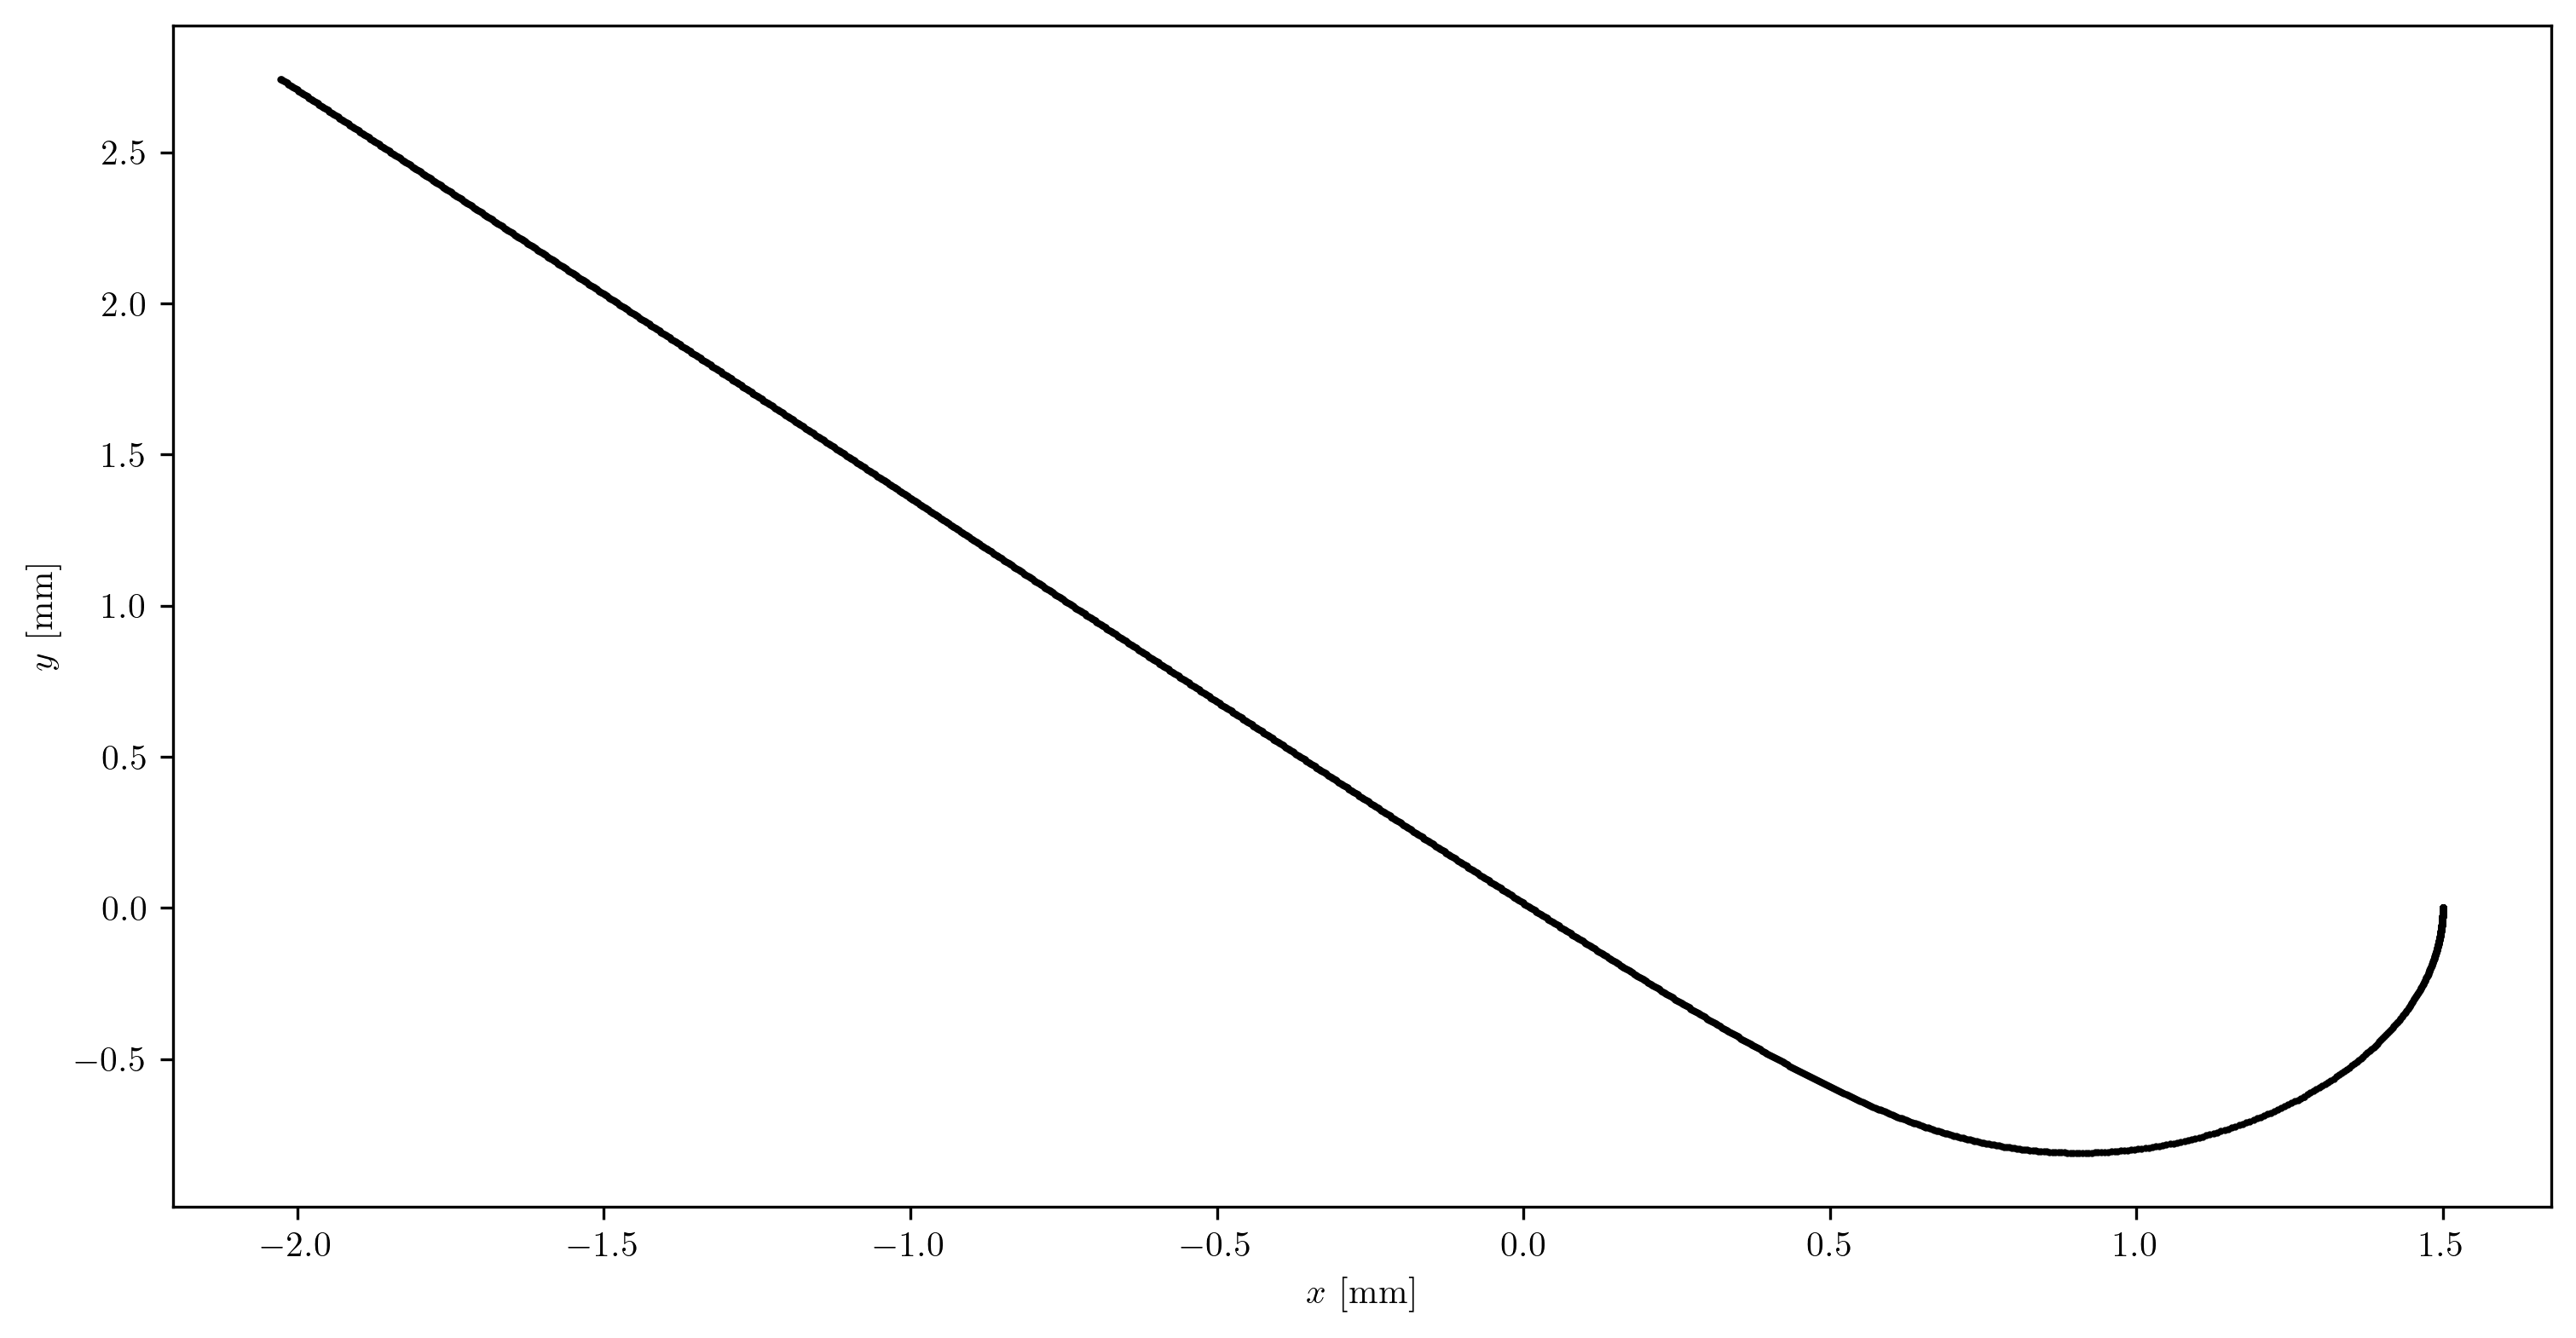

In [13]:
# Plot trajectory in transverse plane:
plt.figure(figsize=(12,6))
plot.plot_xy(data)
plt.show()

#### Focusing length

In [14]:
# Estimate focusing length from Katsuya's formula:
f = calculateF(data)
print(f'f = {np.round(f,10)} mm')

f = 1071.639065661 mm


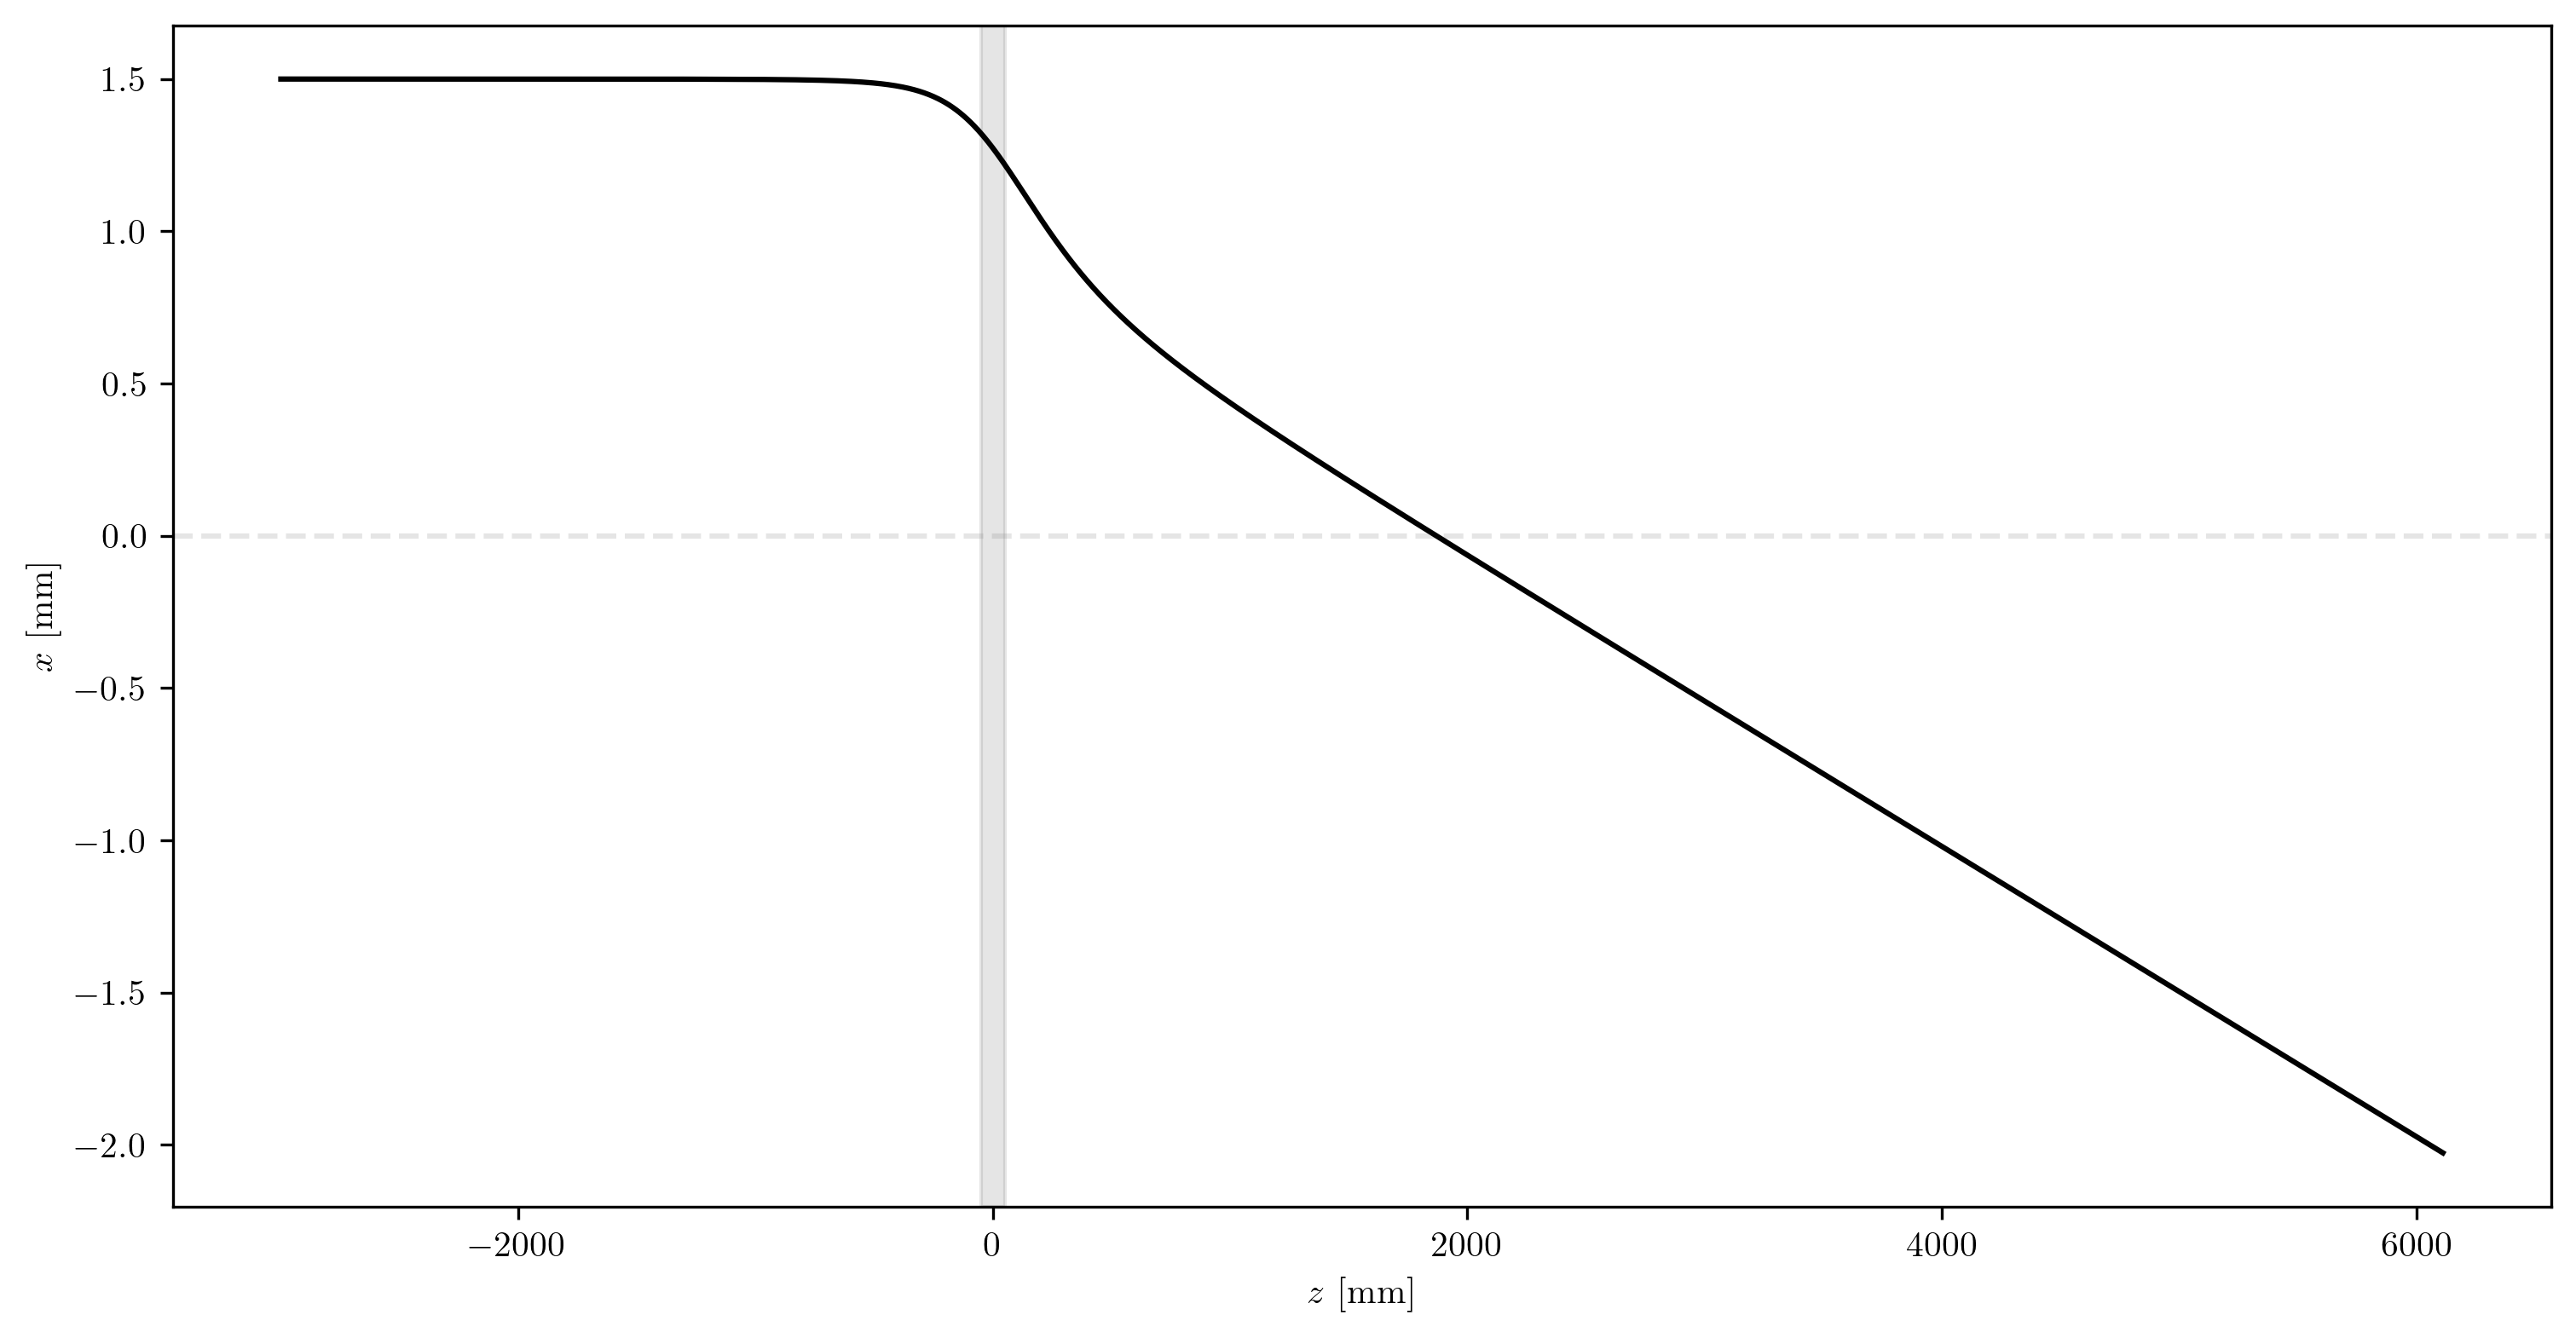

In [15]:
# Plot x vs. z:
plt.figure(figsize=(12,6))
plt.axhline(0, color='gray', alpha=0.2, linestyle='--')
plot.plot_solenoids(n=n, d=d, L=L, zshift=zshift)
plt.plot(data['z'],data['x'], color='black')
plt.xlabel('$z$ [mm]')
plt.ylabel('$x$ [mm]')
plt.show()

### Fields in rotated frame

#### Via rotation of Cartesian components

In [16]:
# Compute B_r and B_phi from rotation:
Br_vals_rot, Bphi_vals_rot = calculate_Br_rotated(data)

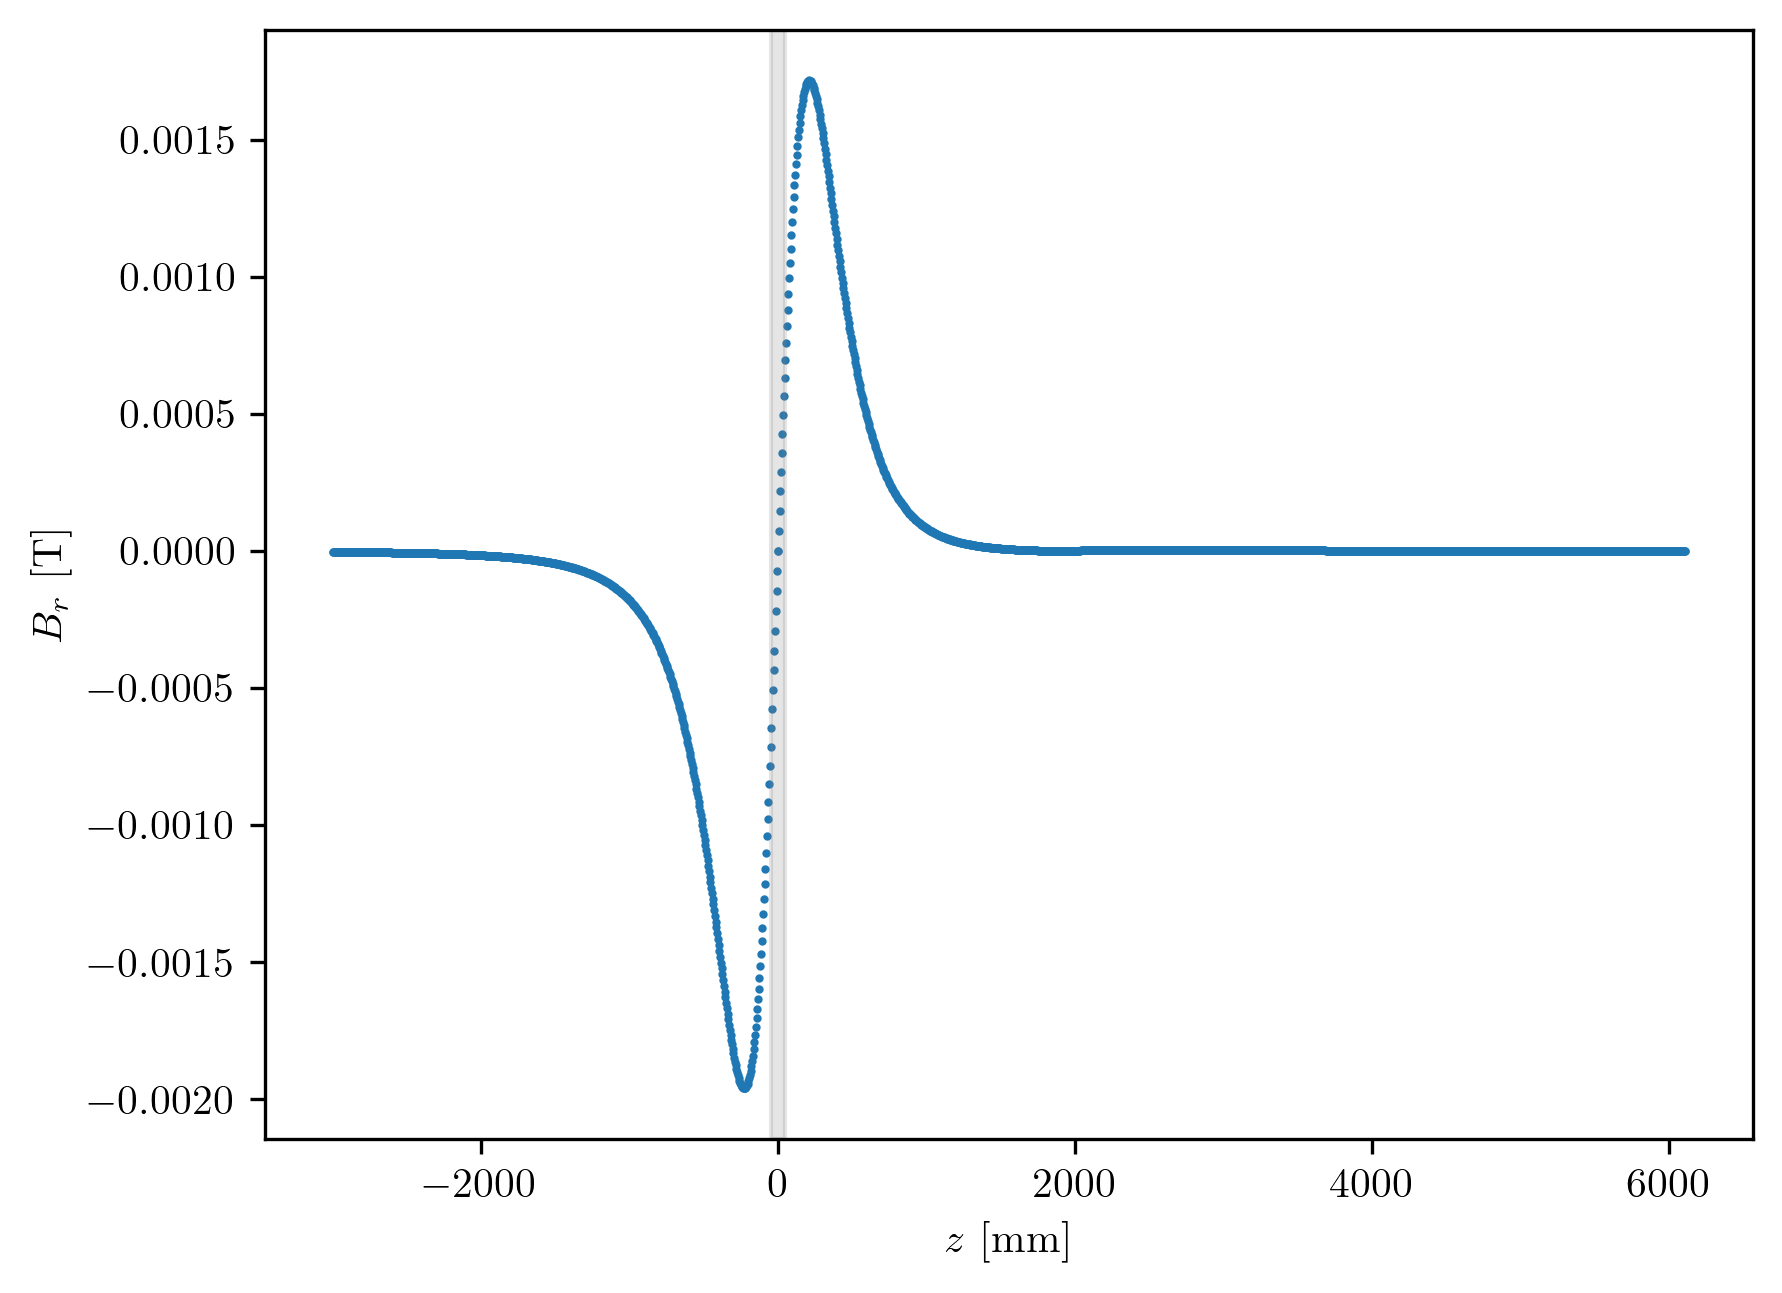

In [17]:
# Plot B_r from rotation:
plt.scatter(data['z'], Br_vals_rot, s=1)
plot.plot_solenoids(n=n, d=d, L=L, zshift=zshift)
plt.xlabel('$z$ [mm]')
plt.ylabel('$B_r$ [T]')
plt.show()

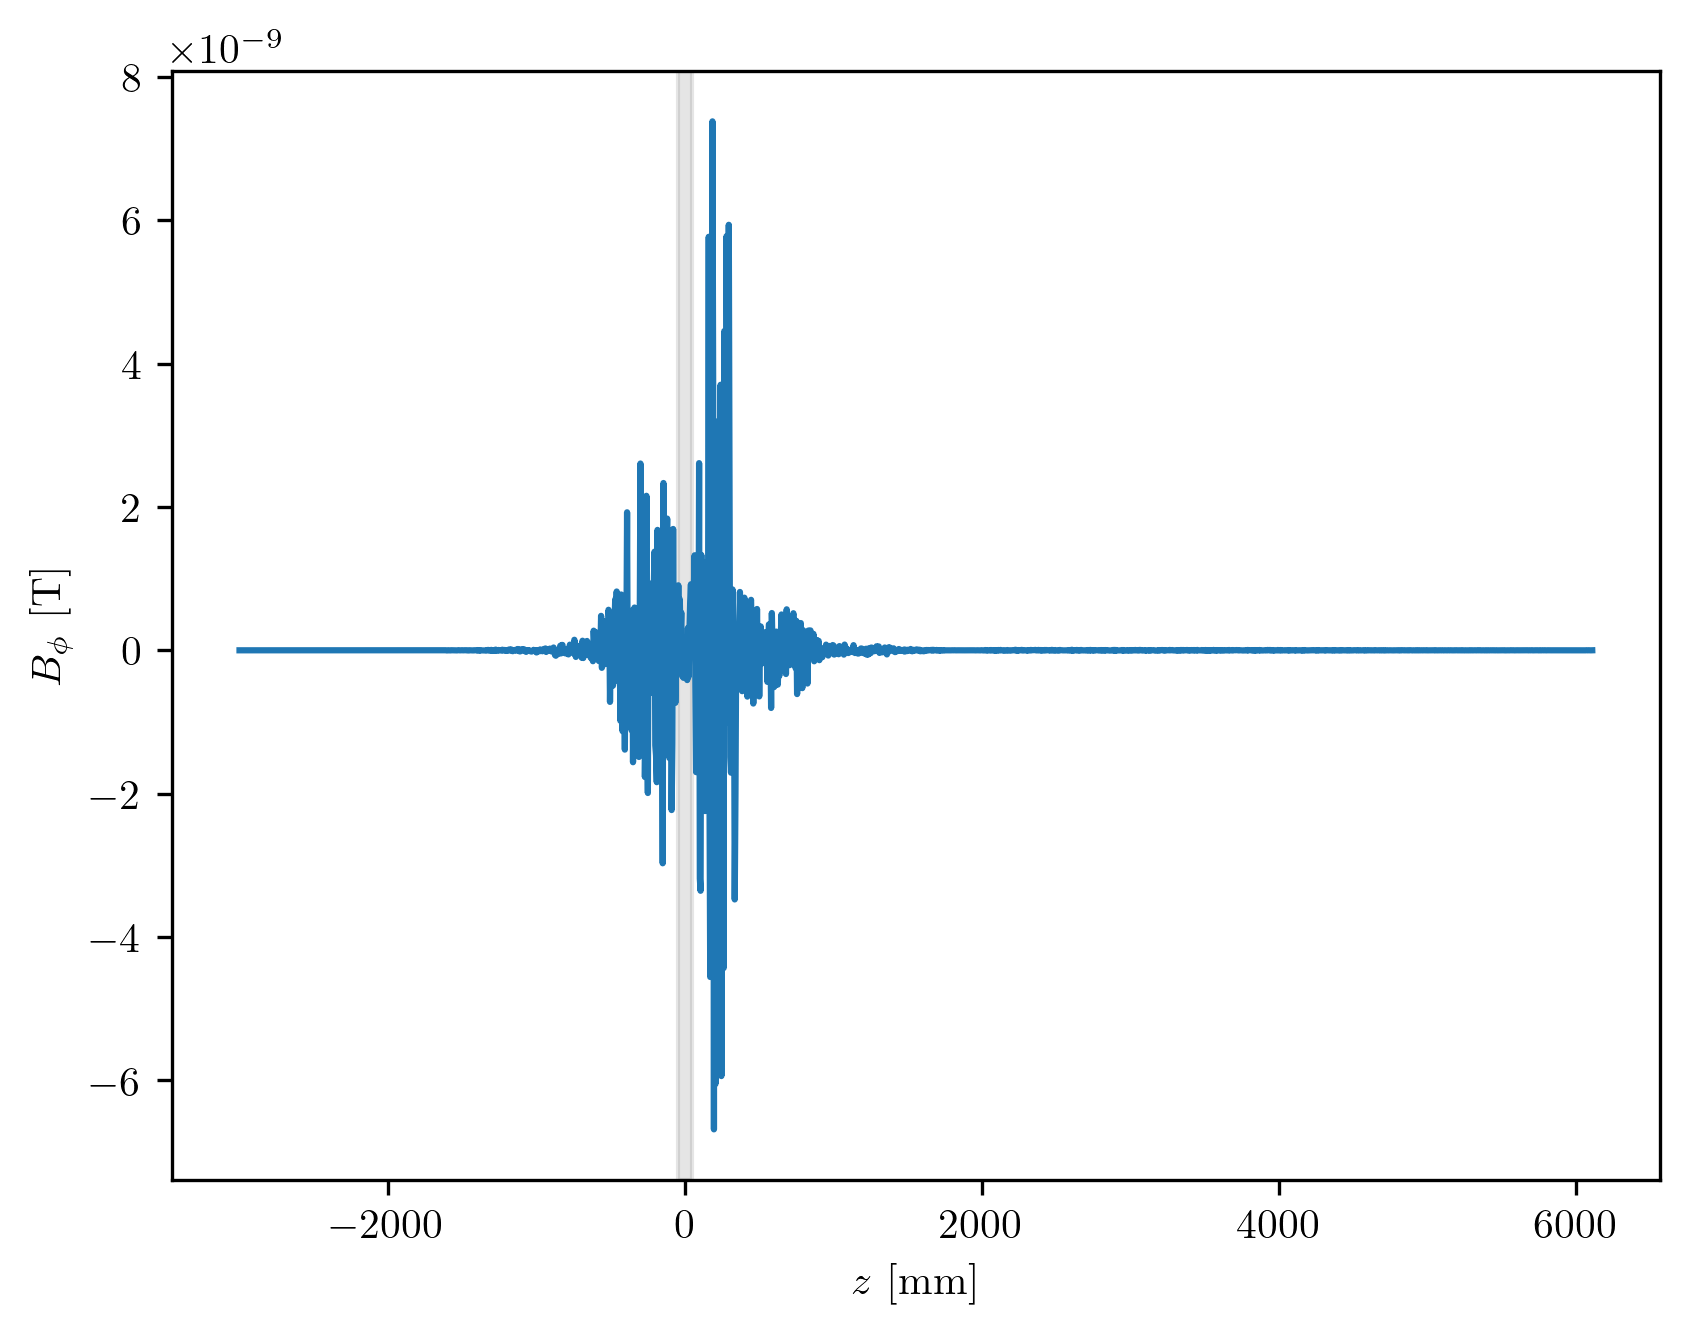

In [18]:
# Plot B_phi from rotation:
# plt.scatter(data['z'], Bphi_vals_rot, s=1)
plt.plot(data['z'], Bphi_vals_rot)
plot.plot_solenoids(n=n, d=d, L=L, zshift=zshift)
plt.xlabel('$z$ [mm]')
plt.ylabel('$B_{\phi}$ [T]')
plt.show()

#### Via approximation using B_z and r 

In [19]:
# Compute B_r from analytical approximation:
Br_vals_ana = calculate_Br_analytic(data)

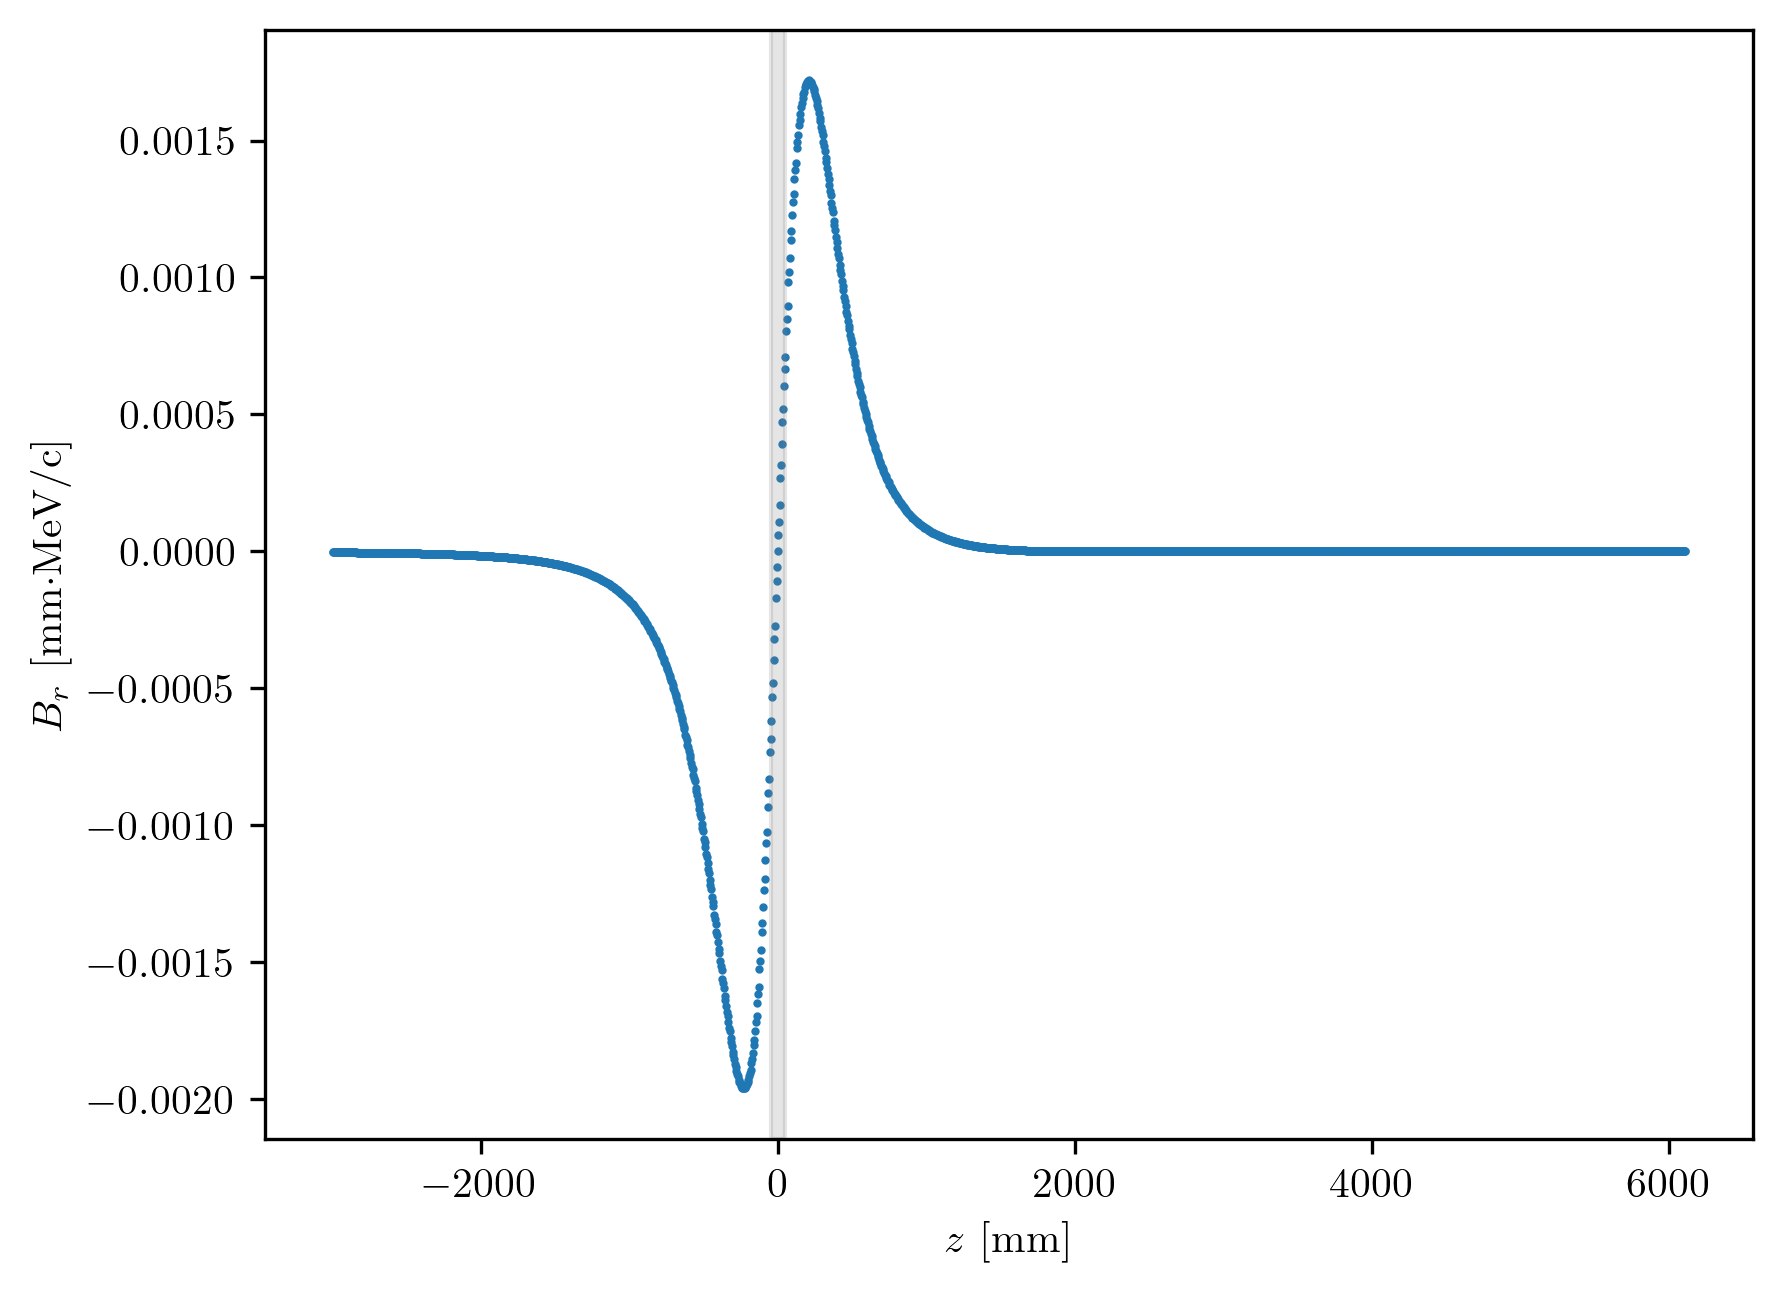

In [20]:
# Plot B_r from analytical approximation:
plt.scatter(data['z'], Br_vals_ana, s=1)
plot.plot_solenoids(n=n, d=d, L=L, zshift=zshift)
plt.xlabel('$z$ [mm]')
plt.ylabel(r'$B_r$ [mm$\cdot$MeV/c]')
plt.show()

#### Comparison

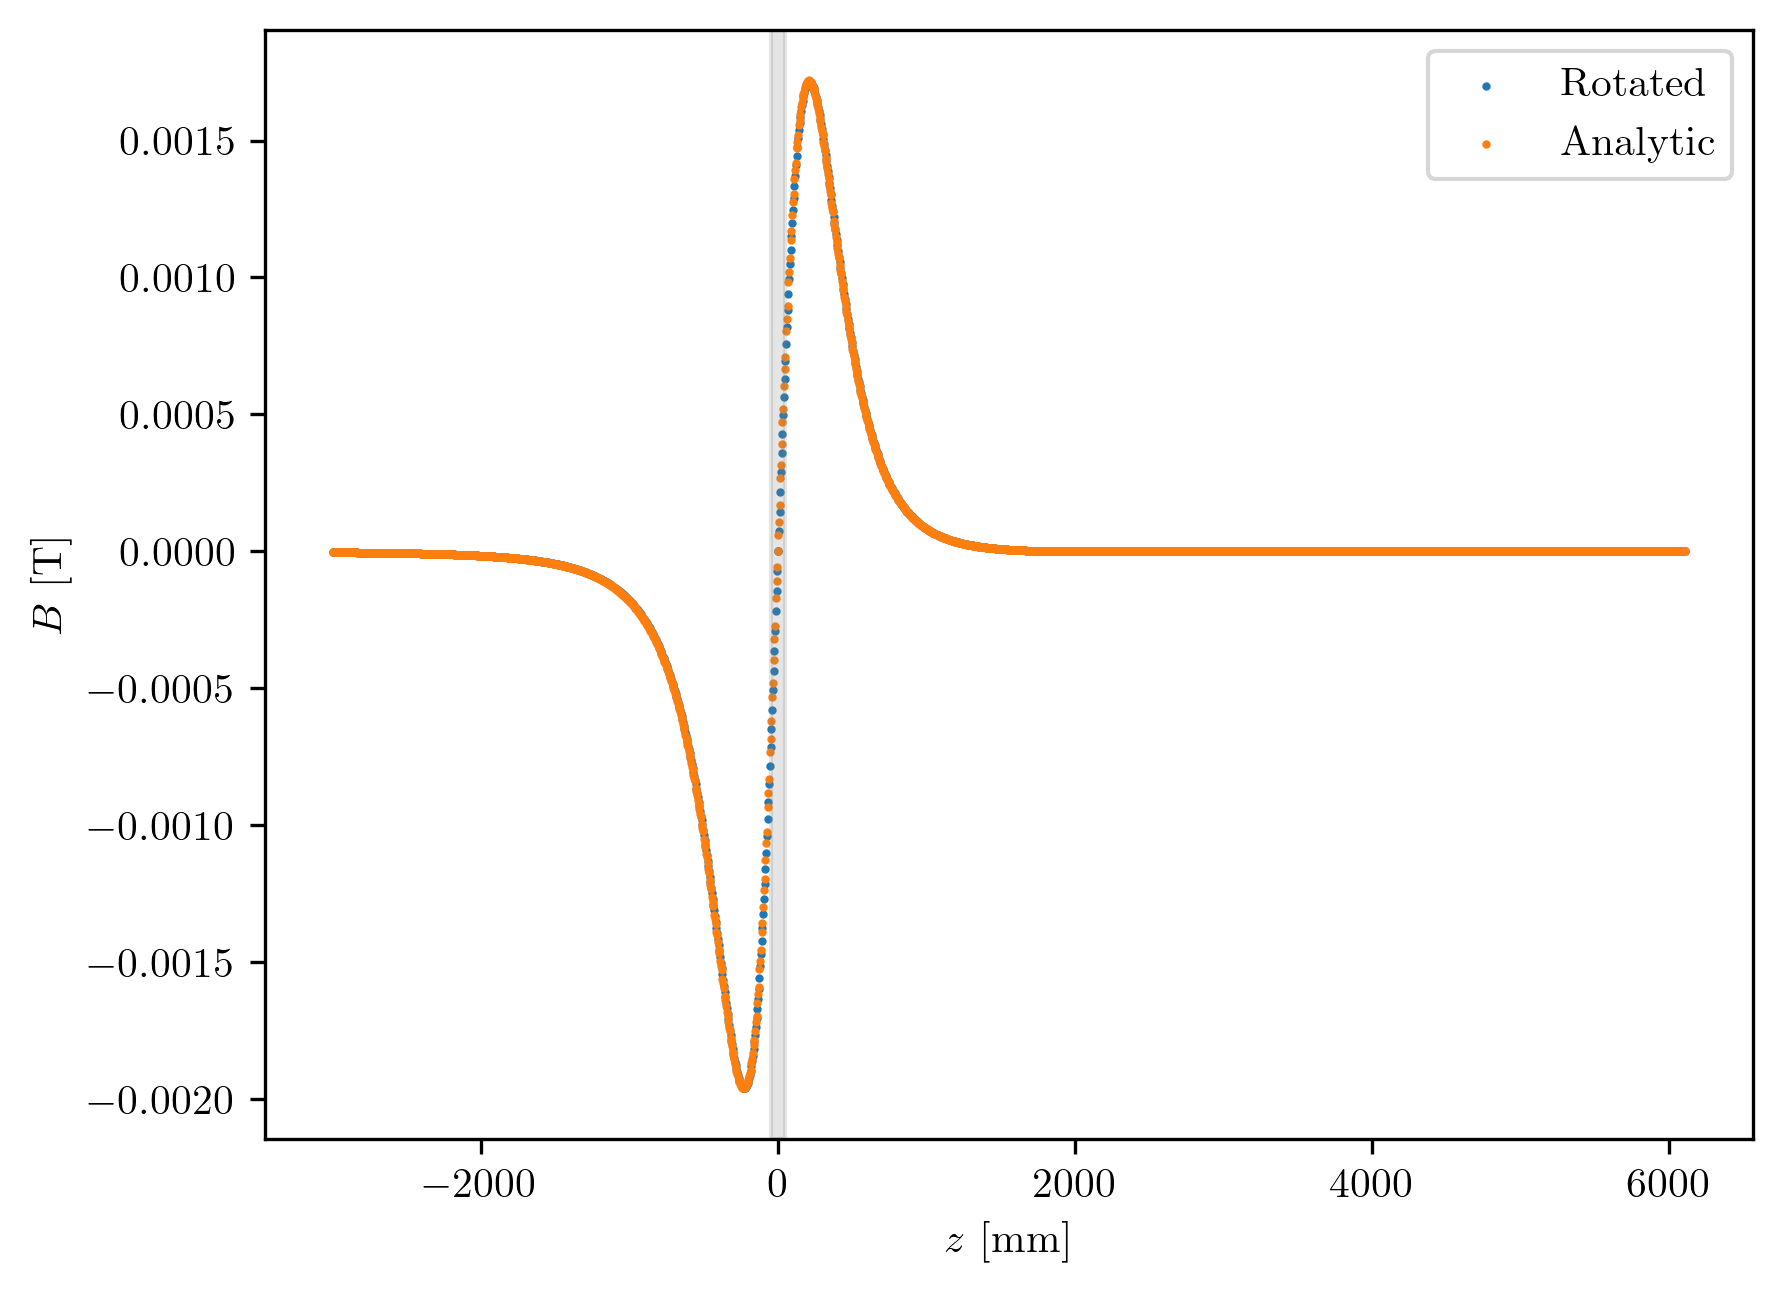

In [21]:
# Compare rotated vs. analytic values:
plt.scatter(data['z'], Br_vals_rot, s=1, label='Rotated')
plt.scatter(data['z'], Br_vals_ana, s=1, label='Analytic')
plot.plot_solenoids(n=n, d=d, L=L, zshift=zshift)
plt.xlabel('$z$ [mm]')
plt.ylabel('$B$ [T]')
plt.legend()
plt.show()